In [1]:
import sys
from pathlib import Path

# Go to project root (REALTIMEFRAUDDETECTION)
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import numpy as np
import pandas as pd
from src.features.TimeFeatures import ComputeTimeFeatures
from src.features.CatEntropy import ComputeCatEntropy
from src.features.CatFreq import ComputeCatFreq
from src.preprocessing.TrainTestSplit import split
from src.preprocessing.PreProcessing import ClientScale

In [3]:
df=pd.read_csv("../data/dataset_PFE_CDM_complet.csv")
df.sort_values(['Account Number','Time'],inplace=True)
df['rank']=df.groupby("Account Number")['Time'].rank(method='first',pct=True)

df['Time']=pd.to_datetime(df['Time'])
df['Date']=df['Time'].dt.date
df['Hour']=df['Time'].dt.hour
df['Age']=df['Age'].astype(int)

In [4]:
traindf,testdf=split(df)

traindf=ComputeTimeFeatures(traindf)
traindf=ComputeCatEntropy(traindf)
traindf=ComputeCatFreq(traindf)

traindf=traindf[['Account Number','Age', 'LogAmount','AmountZScore', 'MovingAvg','MovingStd', 'LogTimeDiff','Hoursin','Hourcos',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq']]

traindf=ClientScale(traindf,'Account Number',
                    ['LogAmount','AmountZScore', 'MovingAvg','MovingStd', 'LogTimeDiff','Hoursin','Hourcos',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq'])

/home/aymanfen/Desktop/RealTimeFraudDetection/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/aymanfen/Desktop/RealTimeFraudDetection/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [5]:
traindf.describe()

,Age,LogAmount,AmountZScore,MovingAvg,MovingStd,LogTimeDiff,Hoursin,Hourcos,TransactionTypeEntropy,ChannelEntropy,CardTypeEntropy,MerchandEntropy,CountryEntropy,CityEntropy,TransactionTypeFreq,ChannelFreq,CardTypeFreq,MerchandFreq,CountryFreq,CityFreq
count,879198.000000,8.791980e+05,8.671980e+05,8.671980e+05,8.671980e+05,8.643730e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05,8.791980e+05
mean,45.347930,2.946795e-17,-1.907560e-18,5.090241e-17,-7.865805e-19,4.983572e-19,-2.072960e-18,8.485800e-18,-1.493993e-11,4.381173e-12,5.436216e-13,7.879672e-14,4.306039e-14,-1.018643e-12,1.656752e-18,1.795757e-17,-3.446043e-17,1.777977e-19,1.409502e-18,-1.137097e-17
std,15.591844,9.988616e-01,9.988457e-01,9.988443e-01,9.988435e-01,9.988515e-01,9.988611e-01,9.988611e-01,1.550265e-10,1.932939e-10,1.825052e-10,1.913476e-10,6.664073e-11,7.921143e-11,9.988578e-01,9.988427e-01,9.530402e-01,9.988425e-01,2.989994e-01,9.988586e-01
min,19.000000,-4.739009e+00,-2.483557e+00,-4.383355e+00,-3.413220e+00,-7.720488e+00,-1.828540e+00,-1.975079e+00,-6.661338e-10,-6.661338e-10,-4.440892e-10,-6.661338e-10,-6.661338e-10,-6.661338e-10,-2.775303e+00,-4.717278e+00,-6.023655e+00,-2.722497e+00,-1.537000e+00,-3.393392e+00
25%,32.000000,-6.741956e-01,-7.553220e-01,-6.780891e-01,-7.126609e-01,-5.250088e-01,-9.993113e-01,-9.949672e-01,-1.110223e-10,-1.110223e-10,-1.110223e-10,-1.110223e-10,0.000000e+00,-2.775558e-11,-8.682163e-01,-4.230013e-01,-4.016137e-01,-3.688276e-01,0.000000e+00,2.901575e-01
50%,45.000000,1.734032e-03,2.104265e-03,-3.316730e-05,-5.029626e-02,1.642628e-01,-1.418627e-03,2.000569e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.261828e-01,-9.161973e-02,-3.879711e-03,-1.115778e-01,0.000000e+00,3.446172e-01
75%,59.000000,6.754604e-01,7.572677e-01,6.772785e-01,6.601921e-01,7.050401e-01,9.965249e-01,9.993926e-01,1.110223e-10,1.110223e-10,1.110223e-10,1.110223e-10,0.000000e+00,2.775558e-11,5.962380e-01,2.615201e-01,2.614613e-01,1.693128e-01,0.000000e+00,3.814878e-01
max,72.000000,4.589985e+00,2.498523e+00,4.408525e+00,4.531326e+00,2.694150e+00,1.868759e+00,1.999684e+00,6.661338e-10,6.661338e-10,4.440892e-10,6.661338e-10,7.771561e-10,6.661338e-10,6.817623e+00,2.282212e+01,2.141704e+01,2.239986e+01,8.485687e+00,8.276032e+00


In [6]:
from src.models.IsolationForest import IsolationForestModel
from src.models.SelfOrganizingMap import SOMModel
from src.models.AutoEncoder import AutoEncoderModel

2026-04-14 14:28:41.797374: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-14 14:28:41.855560: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 14:28:43.502639: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [7]:
traindf = traindf.replace([np.inf, -np.inf], np.nan).fillna(0)

In [8]:
iso=IsolationForestModel(nestimators=300,maxsamples='auto',contamination=0.001)
ae=AutoEncoderModel(inputdim=traindf.shape[1],latentdim=4,lr=0.001,batchsize=256,epochs=50)
som=SOMModel(inputlen=traindf.shape[1],x=20,y=20,sigma=0.8,learning_rate=0.4)

2026-04-14 14:28:44.532320: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
iso.fit(traindf)
ae.fit(traindf)
som.fit(traindf)

Epoch 1/50


2026-04-14 14:28:56.697678: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 63302240 exceeds 10% of free system memory.
2026-04-14 14:28:56.802493: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 63302240 exceeds 10% of free system memory.


3091/3091 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 3.4595 - val_loss: 0.4773
Epoch 2/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4396 - val_loss: 0.4267
Epoch 3/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4266 - val_loss: 0.4248
Epoch 4/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4245 - val_loss: 0.4227
Epoch 5/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4233 - val_loss: 0.4224
Epoch 6/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4227 - val_loss: 0.4224
Epoch 7/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4224 - val_loss: 0.4219
Epoch 8/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4208 - val_loss: 0.4202
Epoch 9/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4194 - val_loss: 0.4188
Epoch 10/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4188 - val_loss: 0.4186
Epoch 11/50
3091/3091 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4183 - val_loss: 0.4174
Epoch 12/50
3091/3091 ━━━━━━━━━━━━━━━━━━━

In [10]:
testdf=ComputeTimeFeatures(testdf)
testdf=ComputeCatEntropy(testdf)
testdf=ComputeCatFreq(testdf)

/home/aymanfen/Desktop/RealTimeFraudDetection/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [11]:
testdf=testdf[['Account Number','Age', 'LogAmount','AmountZScore', 'MovingAvg','MovingStd', 'LogTimeDiff','Hoursin','Hourcos',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq']]

testdf=ClientScale(testdf,'Account Number',
                   ['LogAmount','AmountZScore', 'MovingAvg','MovingStd', 'LogTimeDiff','Hoursin','Hourcos',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq'])

/home/aymanfen/Desktop/RealTimeFraudDetection/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [12]:
testdf = testdf.replace([np.inf, -np.inf], np.nan).fillna(0)

In [18]:
results=testdf.copy()
results['isoscores']=iso.score(testdf)
results['aescores']=ae.score(testdf)
results['somscores']=som.score(testdf)

6901/6901 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step   


In [19]:
from sklearn.preprocessing import minmax_scale

results['isoscores']=minmax_scale(results['isoscores'])
results['somscores']=minmax_scale(results['somscores'])
results['aescores']=minmax_scale(results['aescores'])

<Axes: >

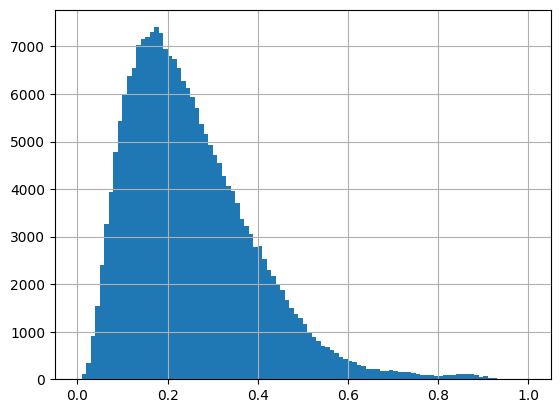

In [20]:
results['isoscores'].hist(bins=100)

<Axes: >

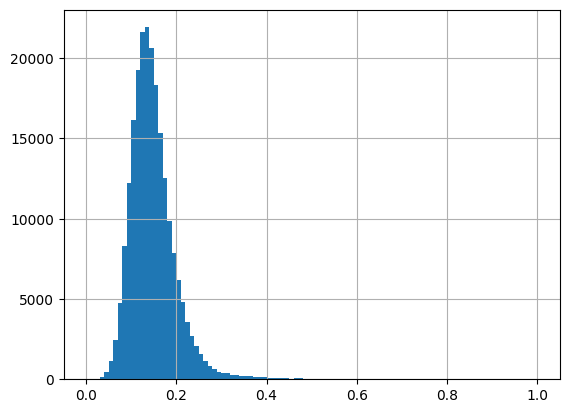

In [24]:
results['somscores'].hist(bins=100)

<Axes: >

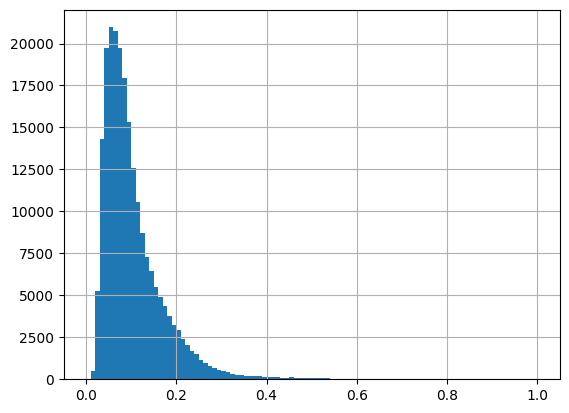

In [25]:
results['aescores'].hist(bins=100)

In [28]:
iso.save(model_name='IF')
ae.save(model_name='AE')
som.save(model_name='SOM')

results.to_csv("../data/results.csv")